Loading data ...
  Rows: 219,800  |  Columns: ['simulation', 'day', 'S', 'K', 'T', 'sigma', 'r', 'bs_price']
        simulation          day            S            K            T  \
count  219800.0000  219800.0000  219800.0000  219800.0000  219800.0000   
mean       99.5000     459.0000   10635.0231    8630.6880       3.1786   
std        57.7344     317.2546    2908.5341    2364.0236       1.2589   
min         0.0000     -90.0000    4767.9354    4903.8000       1.0000   
25%        49.7500     184.0000    8519.9902    6538.4000       2.0873   
50%        99.5000     459.0000    9943.4328    8990.3000       3.1786   
75%       149.2500     734.0000   12052.2577   10624.9000       4.2698   
max       199.0000    1008.0000   29989.1961   12259.5000       5.3571   

             sigma            r     bs_price  
count  219800.0000  219800.0000  219800.0000  
mean        0.1438       0.0259    3281.2293  
std         0.0559       0.0176    2891.1101  
min         0.0840       0.0000     

Model: "MLP_BlackScholes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP for up to 100 epochs (batch_size=512) ...
Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9201368.0000 - mae: 2042.0426 - val_loss: 849930.6875 - val_mae: 724.1942 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 855381.6875 - mae: 680.6620 - val_loss: 192095.5781 - val_mae: 343.1320 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 610486.3750 - mae: 549.2512 - val_loss: 88916.8125 - val_mae: 235.0709 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 531614.3125 - mae: 493.9699 - val_loss: 49505.5977 - val_mae: 175.0150 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 493930.4375 - mae: 466.0405 - val_loss: 29145.3281 - val_mae: 131.9481 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 479005.5625 - mae: 450.9284 - val_loss: 29686.7520 - val_mae: 132.0730 - learning_rate: 0.0010
Epoc

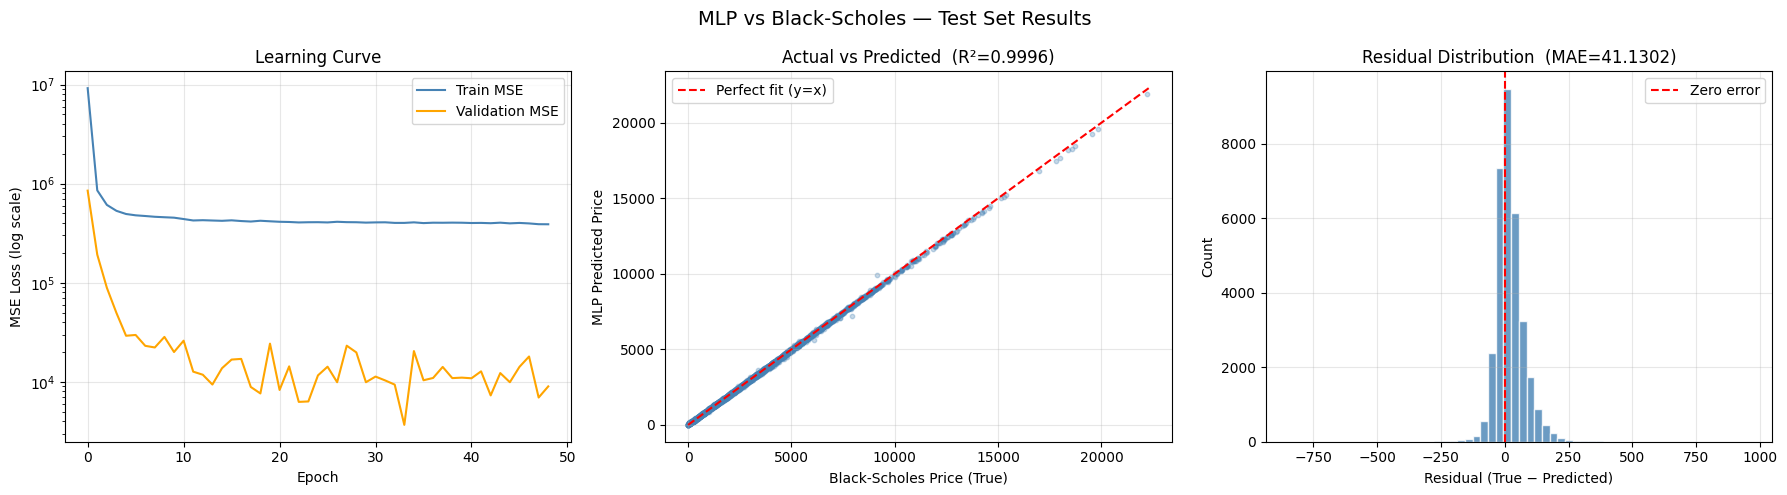


Running sensitivity analysis ...
Saved: mlp_sensitivity.png


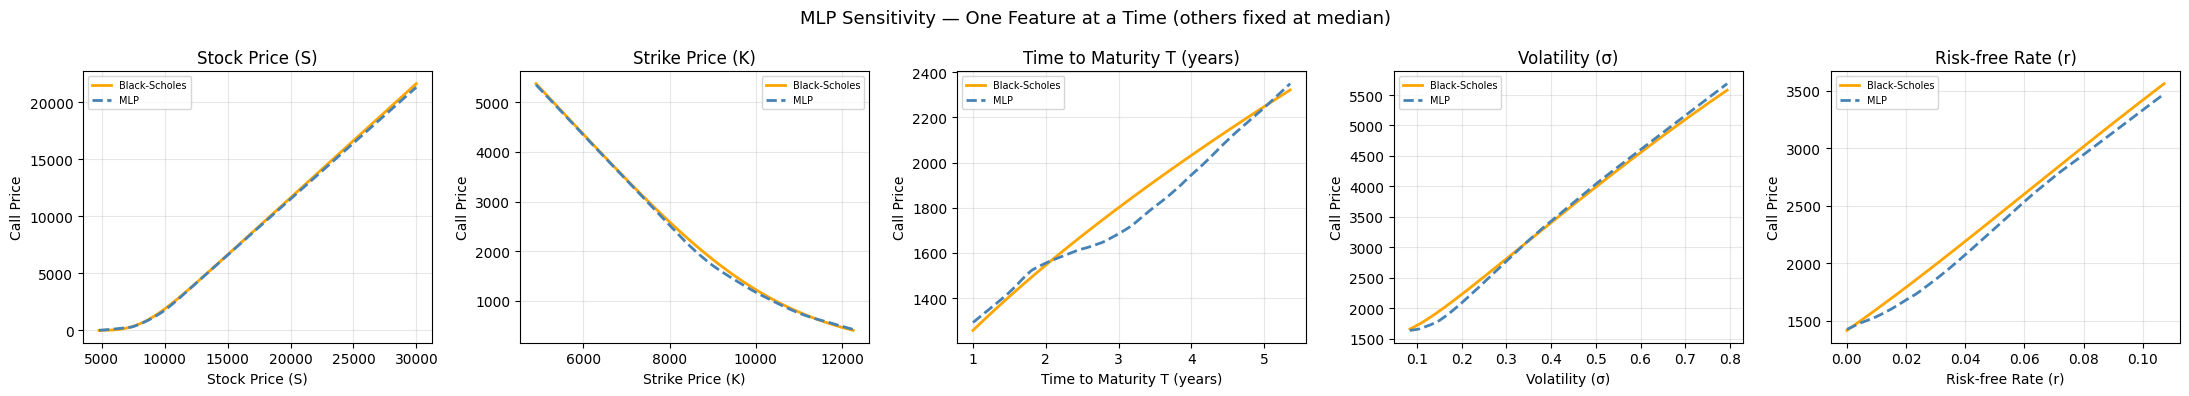


✓ MLP pipeline complete.


In [6]:
"""
MLP Model for Black-Scholes Option Pricing
LSE Statistical Challenge 2026 - Aviva

Dataset columns:
    simulation : simulation number (not used as input feature)
    day        : day index within the simulation (not used as input feature)
    S          : current stock price
    K          : strike price
    T          : time to maturity (years)
    sigma      : volatility
    r          : risk-free interest rate
    bs_price   : Black-Scholes call price (TARGET)

Input features : S, K, T, sigma, r  (5 features)
Target         : bs_price
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import norm as sp_norm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── 1. Load Data ──────────────────────────────────────────────────────────────
# CHANGE THIS PATH to your full 10 000-simulation CSV when running locally
DATA_PATH = "black_scholes_simulation_data_T5_with_price.csv"

print("Loading data ...")
df = pd.read_csv(DATA_PATH)

print(f"  Rows: {len(df):,}  |  Columns: {list(df.columns)}")
print(df.describe().round(4))

# ── 2. Feature & Target Selection ─────────────────────────────────────────────
# 'simulation' and 'day' are identifiers, not inputs to the Black-Scholes formula
FEATURES = ["S", "K", "T", "sigma", "r"]
TARGET   = "bs_price"

X = df[FEATURES].values   # shape (N, 5)
y = df[TARGET].values     # shape (N,)

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Target range         : [{y.min():.4f}, {y.max():.4f}]")

# ── 3. Train / Validation / Test Split ────────────────────────────────────────
# 70% train | 15% validation (monitored during training) | 15% test (held out)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\nTrain size      : {len(X_train):,}")
print(f"Validation size : {len(X_val):,}")
print(f"Test size       : {len(X_test):,}")

# ── 4. Feature Scaling ────────────────────────────────────────────────────────
# StandardScaler transforms each feature to have mean=0 and std=1.
# This is important because S can be ~100 while r is ~0.05 — very different
# scales confuse gradient descent. We fit ONLY on training data to prevent
# data leakage into the validation/test sets.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── 5. Build MLP Model ────────────────────────────────────────────────────────
# Architecture: 5 → 128 → 64 → 32 → 1
#
# Hidden activation — ReLU:
#   ReLU(x) = max(0, x)
#   Simple, fast, avoids the vanishing-gradient problem present in sigmoid/tanh.
#
# Output activation — Softplus:
#   Softplus(x) = ln(1 + e^x)
#   Similar to ReLU but smooth and STRICTLY POSITIVE for all inputs.
#   This guarantees the predicted call price is always > 0, which is
#   financially correct (a call option can never have a negative price).
#
# Dropout (rate=0.20):
#   During each training step, 20% of neurons are randomly switched off.
#   This forces the network to not rely on any single neuron, acting as
#   a regulariser that reduces overfitting. At prediction time, all neurons
#   are active (Keras handles this automatically).
#
# He initialisation:
#   Sets initial weights from a distribution scaled to the layer width,
#   which works best alongside ReLU activations.

def build_mlp(input_dim: int = 5,
              hidden_units: list = [128, 64, 32],
              dropout_rate: float = 0.20,
              learning_rate: float = 1e-3) -> keras.Model:
    """Build and compile a Multi-Layer Perceptron for option price regression."""

    model = keras.Sequential(name="MLP_BlackScholes")

    # Input layer (tells Keras the shape of one sample)
    model.add(layers.Input(shape=(input_dim,), name="input"))

    # Hidden layers: Dense → Dropout → repeat
    for i, units in enumerate(hidden_units):
        model.add(layers.Dense(
            units,
            activation="relu",
            kernel_initializer="he_normal",
            name=f"hidden_{i+1}"
        ))
        model.add(layers.Dropout(dropout_rate, name=f"dropout_{i+1}"))

    # Output layer — single neuron, Softplus keeps output strictly positive
    model.add(layers.Dense(1, activation="softplus", name="output"))

    # Adam optimiser: adaptive learning rate, works well out-of-the-box
    # MSE loss: penalises large errors more heavily — appropriate for pricing
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_mlp()
model.summary()

# ── 6. Callbacks (automatic training helpers) ─────────────────────────────────
# EarlyStopping: stop if validation loss doesn't improve for 15 consecutive
#   epochs, then restore the weights from the best epoch seen so far.
# ReduceLROnPlateau: if validation loss plateaus for 8 epochs, halve the
#   learning rate so the optimiser takes smaller steps to escape the plateau.
# ModelCheckpoint: save the best model to disk during training.

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    filepath="best_mlp_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

# ── 7. Train the Model ────────────────────────────────────────────────────────
# EPOCHS     : maximum training rounds. Early stopping usually ends training
#              well before this limit is reached.
# BATCH_SIZE : how many samples are passed through the network before weights
#              are updated. Larger batches = faster per-epoch time but less
#              frequent updates.
EPOCHS     = 100
BATCH_SIZE = 512

print(f"\nTraining MLP for up to {EPOCHS} epochs (batch_size={BATCH_SIZE}) ...")
t0 = time.time()

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

train_time = time.time() - t0
actual_epochs = len(history.history["loss"])
print(f"\nTraining finished after {actual_epochs} epochs in {train_time:.1f}s.")

# ── 8. Evaluate on Held-Out Test Set ─────────────────────────────────────────
print("\n── Test Set Evaluation ──────────────────────────────────────────────")

def bs_call_vectorised(S, K, T, sigma, r):
    """Vectorised Black-Scholes call price (for timing benchmark)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * sp_norm.cdf(d1) - K * np.exp(-r * T) * sp_norm.cdf(d2)

# Benchmark: how fast is the analytical formula?
t_bs = time.time()
bs_benchmark = bs_call_vectorised(
    X_test[:, 0], X_test[:, 1], X_test[:, 2], X_test[:, 3], X_test[:, 4]
)
bs_time = time.time() - t_bs

# How fast is the MLP?
t_mlp = time.time()
y_pred = model.predict(X_test_sc, batch_size=1024, verbose=0).flatten()
mlp_time = time.time() - t_mlp

# Regression metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
# MAPE: small epsilon avoids division by zero for near-zero prices
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print(f"  MSE  : {mse:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  R²   : {r2:.6f}")
print(f"  MAPE : {mape:.4f}%")
print(f"\n  MLP inference time (test set) : {mlp_time:.4f}s  ({len(X_test):,} samples)")
print(f"  BS  inference time (test set)  : {bs_time:.4f}s  ({len(X_test):,} samples)")
speed_up = bs_time / mlp_time if mlp_time > 0 else float("inf")
print(f"  Speed-up factor               : {speed_up:.2f}x")
print(f"\n  Negative predictions          : {(y_pred < 0).sum()}  (should be 0)")

# ── 9. Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MLP vs Black-Scholes — Test Set Results", fontsize=14)

# (a) Learning curve
ax = axes[0]
ax.plot(history.history["loss"],     label="Train MSE",      color="steelblue")
ax.plot(history.history["val_loss"], label="Validation MSE", color="orange")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (log scale)")
ax.set_title("Learning Curve")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Actual vs Predicted scatter
ax = axes[1]
idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
ax.scatter(y_test[idx], y_pred[idx], alpha=0.3, s=10, color="steelblue")
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit (y=x)")
ax.set_xlabel("Black-Scholes Price (True)")
ax.set_ylabel("MLP Predicted Price")
ax.set_title(f"Actual vs Predicted  (R²={r2:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Residual distribution
ax = axes[2]
residuals = y_test - y_pred
ax.hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Zero error")
ax.set_xlabel("Residual (True − Predicted)")
ax.set_ylabel("Count")
ax.set_title(f"Residual Distribution  (MAE={mae:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_results.png", dpi=150, bbox_inches="tight")
print("\nSaved: mlp_results.png")
plt.show()

# ── 10. Sensitivity Analysis ──────────────────────────────────────────────────
# Vary one input feature at a time while holding all others at their median.
# This shows whether the MLP has learned the correct financial relationships:
#   - Higher S → higher call price
#   - Higher K → lower call price (deeper out of the money)
#   - Higher T → higher price (more time for stock to rise)
#   - Higher sigma → higher price (more uncertainty = more option value)
#   - Higher r → slightly higher price (lower discounted strike)

print("\nRunning sensitivity analysis ...")
medians = np.median(X_train, axis=0)

feature_labels = {
    "S"    : "Stock Price (S)",
    "K"    : "Strike Price (K)",
    "T"    : "Time to Maturity T (years)",
    "sigma": "Volatility (σ)",
    "r"    : "Risk-free Rate (r)"
}

fig2, axes2 = plt.subplots(1, 5, figsize=(22, 4))
fig2.suptitle("MLP Sensitivity — One Feature at a Time (others fixed at median)",
              fontsize=13)

for ax, (feat, label) in zip(axes2, feature_labels.items()):
    fi = FEATURES.index(feat)
    feat_range = np.linspace(X_train[:, fi].min(), X_train[:, fi].max(), 200)

    # Build grid: 200 rows, each identical to medians except for this feature
    grid = np.tile(medians, (200, 1))
    grid[:, fi] = feat_range

    grid_sc   = scaler.transform(grid)
    pred_grid = model.predict(grid_sc, verbose=0).flatten()
    bs_grid   = bs_call_vectorised(grid[:, 0], grid[:, 1], grid[:, 2],
                                    grid[:, 3], grid[:, 4])

    ax.plot(feat_range, bs_grid,   color="orange",    lw=2,   label="Black-Scholes")
    ax.plot(feat_range, pred_grid, color="steelblue", lw=2,
            linestyle="--", label="MLP")
    ax.set_xlabel(label)
    ax.set_ylabel("Call Price")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_sensitivity.png", dpi=150, bbox_inches="tight")
print("Saved: mlp_sensitivity.png")
plt.show()

print("\n✓ MLP pipeline complete.")

In [ ]:
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
print(f"  WMAPE (Weighted Mean Absolute % Error):  {wmape:>10.2f}%")